# RetinaVLM Method 2: HF Direct Load Inference Pipeline

HuggingFace의 8-bit 양자화 체크포인트에서 **직접** 모델을 로드하는 파이프라인.  
별도의 `model.pt` 중간 파일 없이 HF에서 바로 로드합니다.

**핵심 전략 (Method 2):**
1. Llama3 사전학습 가중치로 초기화 (`initialize=True`)
2. HF 체크포인트 다운로드 → int8 역양자화 (float16)
3. **LLM 가중치 제외** - visual_encoder + llama_proj만 로드
4. LLM은 원본 사전학습 가중치 유지 (int8 역양자화 정밀도 손실 방지)

**Method 1 (1_retinavlm_dequantized_inference.ipynb) 대비 장점:**
- 중간 `model.pt` 파일 불필요 (디스크 절약)
- LLM 가중치를 원본 fp16으로 유지 (int8 역양자화 누적 오차 없음)

## 1. Imports & Hydra Config 초기화

In [1]:
import torch
import json
import os
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image
from glob import glob
from datetime import datetime
from collections import Counter

from huggingface_hub import hf_hub_download, snapshot_download
from safetensors.torch import load_file as safetensors_load_file
from omegaconf import OmegaConf

from hydra import compose, initialize_config_dir

from models.retinavlm_wrapper import RetinaVLMConfig
from run.vision_language_pretraining import MiniGPT4Module

# Hydra config 초기화 (노트북에서는 initialize_config_dir 사용)
config_dir = os.path.abspath("configs")
with initialize_config_dir(version_base=None, config_dir=config_dir):
    config = compose(config_name="default")

print("Config loaded!")
print(f"  pretrained_model_dir: {config.pretrained_model_dir}")
print(f"  language_model: {config.model.language_model.model_id}")

/home/ubuntu/bionexus/jgy/miniconda3/envs/oct_llm/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
/home/ubuntu/bionexus/jgy/miniconda3/envs/oct_llm/lib/python3.10/site-packages/timm/models/layers/__init__.py:49: FutureWarning: Importing from timm.models.layers is deprecated, please import via timm.layers
  warnings.warn(f"Importing from {__name__} is deprecated, please import via timm.layers", FutureWarning)
/home/ubuntu/bionexus/jgy/miniconda3/envs/oct_llm/lib/python3.10/site-packages/lightning_fabric/__init__.py:29: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  __import__("pkg_resources").declare_namespace(

Config loaded!
  pretrained_model_dir: /home/ubuntu/bionexus/jgy/.cache/huggingface/hub
  language_model: meta-llama/Meta-Llama-3-8B-Instruct


## 2. 유틸리티 함수 정의

HF 체크포인트 다운로드, int8 역양자화, 키 리매핑 함수들을 정의합니다.

In [2]:
def dequantize_state_dict(state_dict):
    """int8 + SCB 키를 찾아 float16으로 역양자화."""
    dequantized = {}
    scb_keys = {k for k in state_dict if k.endswith('.SCB')}
    weight_format_keys = {k for k in state_dict if k.endswith('.weight_format')}
    skip_keys = scb_keys | weight_format_keys
    n_dequantized = 0

    for key, tensor in state_dict.items():
        if key in skip_keys:
            continue
        scb_key = key.rsplit('.', 1)[0] + '.SCB' if '.' in key else key + '.SCB'
        if tensor.dtype == torch.int8 and scb_key in state_dict:
            scb = state_dict[scb_key]
            w = tensor.float()
            s = scb.float()
            if w.ndim == 2:
                if s.shape[0] == w.shape[1]:
                    deq = w * s.unsqueeze(0) / 127.0
                elif s.shape[0] == w.shape[0]:
                    deq = w * s.unsqueeze(1) / 127.0
                else:
                    print(f"  WARNING: SCB shape {s.shape} != weight shape {w.shape}, skip {key}")
                    dequantized[key] = tensor
                    continue
            else:
                deq = w * s / 127.0
            dequantized[key] = deq.half()
            n_dequantized += 1
        else:
            dequantized[key] = tensor

    print(f"  [dequantize] {n_dequantized} int8 tensors → float16")
    return dequantized


def load_hf_checkpoint_files(repo_id, subfolder, cache_dir=None):
    """HF 체크포인트 파일들을 다운로드하고 합쳐서 state_dict로 반환."""
    local_dir = snapshot_download(
        repo_id,
        allow_patterns=[
            f"{subfolder}/*.safetensors",
            f"{subfolder}/*.bin",
            f"{subfolder}/model.safetensors.index.json",
        ],
        cache_dir=cache_dir,
    )
    model_dir = os.path.join(local_dir, subfolder)

    index_file = os.path.join(model_dir, "model.safetensors.index.json")
    if os.path.exists(index_file):
        with open(index_file) as f:
            index = json.load(f)
        shard_files = set(index["weight_map"].values())
        print(f"  [load_hf] Found {len(shard_files)} sharded safetensors files")
    else:
        shard_files = [f for f in os.listdir(model_dir)
                       if f.endswith('.safetensors') or f.endswith('.bin')]
        print(f"  [load_hf] Found {len(shard_files)} checkpoint files")

    full_state_dict = {}
    for shard_file in sorted(shard_files):
        filepath = os.path.join(model_dir, shard_file)
        if filepath.endswith('.safetensors'):
            shard = safetensors_load_file(filepath)
        else:
            shard = torch.load(filepath, map_location="cpu")
            if 'state_dict' in shard:
                shard = shard['state_dict']
        full_state_dict.update(shard)
        print(f"    Loaded {shard_file}: {len(shard)} tensors")

    print(f"  [load_hf] Total: {len(full_state_dict)} tensors")
    return full_state_dict


def remap_checkpoint_keys(ckpt_state_dict, model_state_dict):
    """체크포인트 키를 모델 키에 맞게 리매핑."""
    expected_keys = set(model_state_dict.keys())

    # Step 1: "model." prefix 제거
    stripped = {}
    for k, v in ckpt_state_dict.items():
        new_k = k[len("model."):] if k.startswith("model.") else k
        stripped[new_k] = v

    # Step 2: llm.model → llama_model 변환
    remap_rules = [
        ("llm.model.model.", "llama_model.model."),
        ("llm.model.lm_head.", "llama_model.lm_head."),
    ]
    remapped = {}
    for k, v in stripped.items():
        new_k = k
        for old_pattern, new_pattern in remap_rules:
            new_k = new_k.replace(old_pattern, new_pattern)
        remapped[new_k] = v

    # Step 3: 중복 키 생성 (llama_model ↔ llm.model alias)
    alias_pairs = [
        ("llama_model.model.", "llm.model.model."),
        ("llama_model.lm_head.", "llm.model.lm_head."),
    ]
    extra = {}
    for k, v in remapped.items():
        for prefix_a, prefix_b in alias_pairs:
            if k.startswith(prefix_a):
                alt_k = prefix_b + k[len(prefix_a):]
                if alt_k not in remapped:
                    extra[alt_k] = v
            elif k.startswith(prefix_b):
                alt_k = prefix_a + k[len(prefix_b):]
                if alt_k not in remapped:
                    extra[alt_k] = v
    remapped.update(extra)

    # Step 4: ResNet name→index for feature_tokens_model
    resnet_name_to_idx = {
        "conv1": "0", "bn1": "1", "relu": "2", "maxpool": "3",
        "layer1": "4", "layer2": "5", "layer3": "6", "layer4": "7",
    }
    ve_extra = {}
    for k, v in remapped.items():
        if k.startswith("visual_encoder.model."):
            suffix = k[len("visual_encoder.model."):]
            parts = suffix.split(".", 1)
            child_name = parts[0]
            if child_name in resnet_name_to_idx:
                idx = resnet_name_to_idx[child_name]
                rest = "." + parts[1] if len(parts) > 1 else ""
                ftm_key = f"visual_encoder.feature_tokens_model.{idx}{rest}"
                if ftm_key not in remapped:
                    ve_extra[ftm_key] = v
    remapped.update(ve_extra)

    # 결과 확인
    remapped_keys = set(remapped.keys())
    matched = expected_keys & remapped_keys
    missing = expected_keys - remapped_keys
    unexpected = remapped_keys - expected_keys

    print(f"  [remap] Matched={len(matched)}/{len(expected_keys)}, Missing={len(missing)}, Unexpected={len(unexpected)}")
    if missing:
        print(f"  [remap] Sample missing (first 5): {sorted(missing)[:5]}")
    if unexpected:
        print(f"  [remap] Sample unexpected (first 5): {sorted(unexpected)[:5]}")

    return remapped


print("Utility functions defined.")

Utility functions defined.


## 3. 모델 로드 (Method 2: HF Direct)

1. Llama3 사전학습 가중치로 모델 생성 (`initialize=True`)
2. HF 체크포인트 다운로드 + int8 역양자화
3. **LLM 가중치 제외** → visual_encoder + llama_proj만 로드
4. LLM은 원본 fp16 가중치 유지

In [3]:
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
load_start = time.time()

# ── Step 1: Config 준비 ──
print("[Step 1] Config 준비...")
rvlm_config = RetinaVLMConfig.from_pretrained(
    "RobbieHolland/RetinaVLM", subfolder="RetinaVLM-Specialist"
)
rvlm_config.update(config)
rvlm_config.model.checkpoint_path = None
rvlm_config.model.language_model.initialize = True  # Llama3 사전학습 가중치 로드

# ── Step 2: 모델 생성 (Llama3 포함) ──
print("\n[Step 2] 모델 구조 생성 (Llama3 사전학습 가중치 포함)...")
step2_start = time.time()
model = MiniGPT4Module(rvlm_config, device=DEVICE).model.eval()
step2_time = time.time() - step2_start
print(f"  모델 생성 완료: {step2_time:.1f}s")

# ── Step 3: HF 체크포인트 다운로드 + 역양자화 ──
print("\n[Step 3] HF 체크포인트 다운로드 및 역양자화...")
step3_start = time.time()
ckpt_state_dict = load_hf_checkpoint_files(
    "RobbieHolland/RetinaVLM",
    "RetinaVLM-Specialist",
    cache_dir=config.pretrained_model_dir,
)
ckpt_state_dict = dequantize_state_dict(ckpt_state_dict)
step3_time = time.time() - step3_start
print(f"  체크포인트 처리 완료: {step3_time:.1f}s")

# ── Step 4: 키 리매핑 + 선택적 로드 ──
print("\n[Step 4] 키 리매핑 및 선택적 가중치 로드...")
step4_start = time.time()
model_state_dict = model.state_dict()
print(f"  Model keys: {len(model_state_dict)}, Checkpoint keys: {len(ckpt_state_dict)}")

remapped_dict = remap_checkpoint_keys(ckpt_state_dict, model_state_dict)

# LLM 가중치 제외 (int8 역양자화 정밀도 손실 방지)
llm_prefixes = ("llm.", "llama_model.")
filtered_dict = {k: v for k, v in remapped_dict.items()
                 if not any(k.startswith(p) for p in llm_prefixes)}
n_llm_excluded = len(remapped_dict) - len(filtered_dict)
print(f"  Filtered: {len(remapped_dict)} → {len(filtered_dict)} (LLM {n_llm_excluded}개 제외)")

result = model.load_state_dict(filtered_dict, strict=False)
step4_time = time.time() - step4_start
print(f"  load_state_dict: missing={len(result.missing_keys)}, unexpected={len(result.unexpected_keys)}")
print(f"  키 로드 완료: {step4_time:.1f}s")

# 메모리 정리
del ckpt_state_dict, model_state_dict, remapped_dict, filtered_dict
torch.cuda.empty_cache()

model = model.to(DEVICE)
total_load_time = time.time() - load_start

print(f"\n{'='*50}")
print(f"  모델 로드 완료!")
print(f"  총 소요 시간: {total_load_time:.1f}s")
print(f"    Step 2 (모델 생성): {step2_time:.1f}s")
print(f"    Step 3 (체크포인트): {step3_time:.1f}s")
print(f"    Step 4 (키 로드):   {step4_time:.1f}s")
print(f"  Device: {DEVICE}")
print(f"{'='*50}")

[Step 1] Config 준비...


`torch_dtype` is deprecated! Use `dtype` instead!



[Step 2] 모델 구조 생성 (Llama3 사전학습 가중치 포함)...
Creating new MiniGPT4 model
Loading image encoder
Creating blank encoder for later weight loading.
Loading image encoder Done
Loading language model


Loading weights: 100%|██████████| 291/291 [00:01<00:00, 165.83it/s]


Loading language model Done
Linear projection Linear(in_features=2048, out_features=4096, bias=True)
MiniGPT-4 has 8392704 trainable parameters
Creating an entirely new MiniGPT4 adapter (this will be overwritten by pretrained model if loaded from API)
  모델 생성 완료: 6.8s

[Step 3] HF 체크포인트 다운로드 및 역양자화...


Fetching 3 files: 100%|██████████| 3/3 [00:00<00:00, 4014.97it/s]


  [load_hf] Found 2 sharded safetensors files
    Loaded model-00001-of-00002.safetensors: 725 tensors
    Loaded model-00002-of-00002.safetensors: 558 tensors
  [load_hf] Total: 1283 tensors
  [dequantize] 224 int8 tensors → float16
  체크포인트 처리 완료: 44.9s

[Step 4] 키 리매핑 및 선택적 가중치 로드...
  Model keys: 1220, Checkpoint keys: 611
  [remap] Matched=1220/1220, Missing=0, Unexpected=0
  Filtered: 1220 → 638 (LLM 582개 제외)
  load_state_dict: missing=582, unexpected=0
  키 로드 완료: 0.5s

  모델 로드 완료!
  총 소요 시간: 59.9s
    Step 2 (모델 생성): 6.8s
    Step 3 (체크포인트): 44.9s
    Step 4 (키 로드):   0.5s
  Device: cuda


## 4. 가중치 검증

Visual Encoder, Projection Layer, LLM 가중치가 정상적으로 로드되었는지 확인합니다.

In [4]:
print("=" * 60)
print(" 가중치 검증")
print("=" * 60)

# Visual Encoder
ve_params = dict(model.visual_encoder.named_parameters())
zero_ve = sum(1 for p in ve_params.values() if (p.float() == 0).all().item())
print(f"\n[Visual Encoder] {zero_ve}/{len(ve_params)} all-zero params")
for name, param in list(model.visual_encoder.named_parameters())[:3]:
    p = param.float()
    print(f"  {name}: shape={list(p.shape)}, mean={p.mean():.6f}, std={p.std():.6f}")

# Projection Layer
print(f"\n[Projection Layer (llama_proj)]")
for name, param in model.llama_proj.named_parameters():
    p = param.float()
    print(f"  {name}: shape={list(p.shape)}, mean={p.mean():.6f}, std={p.std():.6f}")

# LLM (첫 3개 + 마지막 레이어)
print(f"\n[LLM - 원본 사전학습 가중치 유지 확인]")
for name, param in list(model.llm.model.named_parameters())[:3]:
    p = param.float()
    print(f"  {name}: mean={p.mean():.6f}, std={p.std():.6f}")

# LLM 단독 텍스트 생성 테스트
print(f"\n[LLM 단독 생성 테스트]")
tokenizer = model.llm.tokenizer
test_prompt = "The capital of France is"
input_ids = tokenizer(test_prompt, return_tensors="pt").input_ids.to(DEVICE)
model_param = next(model.parameters())
input_embeds = model.llama_model.model.embed_tokens(input_ids).to(dtype=model_param.dtype)
with torch.no_grad(), torch.cuda.amp.autocast(dtype=torch.float16):
    llm_out = model.llama_model.generate(
        inputs_embeds=input_embeds, max_new_tokens=30, do_sample=False,
    )
llm_text = tokenizer.decode(llm_out[0], skip_special_tokens=True)
print(f"  Prompt: '{test_prompt}'")
print(f"  Output: '{llm_text}'")

 가중치 검증

[Visual Encoder] 0/159 all-zero params
  model.conv1.weight: shape=[64, 1, 7, 7], mean=0.001029, std=0.070696
  model.bn1.weight: shape=[64], mean=0.923258, std=0.085509
  model.bn1.bias: shape=[64], mean=0.440203, std=0.326869

[Projection Layer (llama_proj)]
  weight: shape=[4096, 2048], mean=-0.000028, std=0.045305
  bias: shape=[4096], mean=-0.000130, std=0.030056

[LLM - 원본 사전학습 가중치 유지 확인]
  model.embed_tokens.weight: mean=0.000018, std=0.009307
  model.layers.0.self_attn.q_proj.weight: mean=-0.000000, std=0.017713
  model.layers.0.self_attn.k_proj.weight: mean=-0.000007, std=0.025728

[LLM 단독 생성 테스트]


/tmp/ipykernel_159865/1742108443.py:32: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.no_grad(), torch.cuda.amp.autocast(dtype=torch.float16):
The attention mask and the pad token id were not set. As a consequence, you may observe unexpected behavior. Please pass your input's `attention_mask` to obtain reliable results.
Setting `pad_token_id` to `eos_token_id`:128009 for open-end generation.
The attention mask is not set and cannot be inferred from input because pad token is same as eos token. As a consequence, you may observe unexpected behavior. Please pass your input's `attention_mask` to obtain reliable results.


  Prompt: 'The capital of France is'
  Output: ' Paris, which is located in the north-central part of the country. Paris is the most populous city in France and is known for its stunning architecture,'


## 5. 실험 파라미터 설정

추론에 사용할 파라미터들을 한 곳에서 관리합니다. **여기만 수정하면 됩니다.**

In [5]:
# =====================================================
#  실험 파라미터 (여기만 수정하세요)
# =====================================================

EXPERIMENT_NAME = "exp_method2_001_baseline"    # 실험 이름
IMAGE_DIR = "dataset/processed_images"           # OCT 이미지 디렉토리
OUTPUT_DIR = f"outputs/{EXPERIMENT_NAME}"        # 결과 저장 디렉토리
MAX_IMAGES = None                                # 추론할 이미지 수 (None=전체)
MAX_NEW_TOKENS = 300                             # 생성할 최대 토큰 수

# 질의 목록 (여러 쿼리로 실험 가능)
QUERIES = {
    "report": "Write a detailed clinical report describing this OCT scan. Identify any visible biomarkers such as drusen, fluid, or atrophy.",
    "biomarker": "List all visible biomarkers in this OCT image and their severity (mild, moderate, severe).",
    "diagnosis": "Based on this OCT scan, what is the most likely diagnosis? Provide reasoning.",
}

# 사용할 쿼리 선택
ACTIVE_QUERY = "report"

os.makedirs(OUTPUT_DIR, exist_ok=True)
print(f"Experiment: {EXPERIMENT_NAME}")
print(f"Output dir: {OUTPUT_DIR}")
print(f"Active query: '{ACTIVE_QUERY}'")
print(f"Max tokens: {MAX_NEW_TOKENS}")
print(f"Query: {QUERIES[ACTIVE_QUERY][:80]}...")

Experiment: exp_method2_001_baseline
Output dir: outputs/exp_method2_001_baseline
Active query: 'report'
Max tokens: 300
Query: Write a detailed clinical report describing this OCT scan. Identify any visible ...


## 6. 배치 추론 + 로그 기록

모든 이미지에 대해 추론을 수행하고, 결과와 소요 시간을 기록합니다.  
Method 2에서는 `model.query()`를 직접 호출합니다 (RetinaVLM wrapper의 `forward()` 대신).

In [6]:
import scipy.ndimage

def preprocess_image(image_path):
    """OCT 이미지를 모델 입력 텐서로 변환 (1x1x192x192, float16).
    모델의 visual encoder conv1은 1채널 입력을 기대하므로 grayscale로 변환."""
    img = Image.open(image_path).convert("L")  # 항상 grayscale로 변환
    img_np = np.array(img)

    # Grayscale → 1xHxW
    img_np = img_np[np.newaxis, :, :]

    # 192x192 리사이즈
    if img_np.shape[1] != 192 or img_np.shape[2] != 192:
        zoom_factors = [1, 192 / img_np.shape[1], 192 / img_np.shape[2]]
        img_np = scipy.ndimage.zoom(img_np, zoom_factors, order=1)

    # 정규화 (0-255 → 0-1)
    if not np.issubdtype(img_np.dtype, np.floating):
        img_np = img_np.astype(np.float32) / 255.0

    img_tensor = torch.from_numpy(img_np).unsqueeze(0)  # [1, 1, 192, 192]
    model_param = next(model.parameters())
    return img_tensor.to(device=model_param.device, dtype=model_param.dtype)


query_text = QUERIES[ACTIVE_QUERY]
image_files = sorted(glob(os.path.join(IMAGE_DIR, "*.png")))
if MAX_IMAGES:
    image_files = image_files[:MAX_IMAGES]

print(f"Total images: {len(image_files)}")
print(f"Query type: {ACTIVE_QUERY}")
print("-" * 70)

results = []
total_start = time.time()

for i, image_path in enumerate(image_files):
    fname = os.path.basename(image_path)
    img_tensor = preprocess_image(image_path)

    start = time.time()
    with torch.no_grad():
        outputs = model.query(
            img_tensor,
            [query_text],
            answer_preamble=[''],
            max_new_tokens=MAX_NEW_TOKENS,
            output_only=True,
            return_samples=False,
        )
    elapsed = time.time() - start

    response = outputs[0]
    n_words = len(response.split())

    results.append({
        "image": fname,
        "query_type": ACTIVE_QUERY,
        "response": response,
        "n_words": n_words,
        "time_sec": round(elapsed, 2),
    })

    print(f"[{i+1}/{len(image_files)}] {fname[:40]}... | {n_words} words | {elapsed:.1f}s")

total_elapsed = time.time() - total_start
print("-" * 70)
print(f"Total: {len(results)} images | {total_elapsed:.1f}s | avg {total_elapsed/len(results):.1f}s/image")

# DataFrame으로 변환
df_results = pd.DataFrame(results)
df_results.head()

Total images: 28
Query type: report
----------------------------------------------------------------------


/home/ubuntu/bionexus/jgy/OCT_LLM_XAI/SpecialistVLMs/models/mini_gpt4.py:167: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  return torch.cuda.amp.autocast(dtype=dtype)
Setting `pad_token_id` to `eos_token_id`:128009 for open-end generation.


Inputs torch.Size([1, 112, 4096])


Setting `pad_token_id` to `eos_token_id`:128009 for open-end generation.


[1/28] 1-16045247-25-FNUIJLKAQMPOPZIFPBDWMNIKO+... | 46 words | 3.6s
Inputs torch.Size([1, 112, 4096])


...

Setting `pad_token_id` to `eos_token_id`:128009 for open-end generation.


[26/28] 8-16042175-25-TWYFYJKMHGNUHTEURQUCNRDCG+... | 53 words | 1.6s
Inputs torch.Size([1, 112, 4096])


Setting `pad_token_id` to `eos_token_id`:128009 for open-end generation.


[27/28] 9-16761780-25-BLOGOCNHJGPEBCVUKPPXTLCZP+... | 55 words | 1.4s
Inputs torch.Size([1, 112, 4096])
[28/28] Normal-macular-OCT-1.png... | 33 words | 0.9s
----------------------------------------------------------------------
Total: 28 images | 52.1s | avg 1.9s/image


,image,query_type,response,n_words,time_sec
0,1-16045247-25-FNUIJLKAQMPOPZIFPBDWMNIKO+XKIVNL...,report,The OCT scan reveals a large drusenoid PED wit...,46,3.58
1,11-17051433-25-JMTCWVPJKJLMJDKPBHMJUBDON+XRKAB...,report,The OCT image shows a moderate volume of subre...,62,4.67
2,13-16042134-25-NVVLQFRZKQQJDNJTHTBNSCTDX+XLMBI...,report,The OCT scan shows a central drusenoid PED wit...,47,9.72
3,14-17046871-25-FPEVMAPUKEEFFVLBRONZIUQSI+XQUJY...,report,The OCT scan shows an area of RPE and outer re...,52,1.65
4,15-16041859-25-LHQXOJWMFMLUQAJZCCSONQGIT+XBQWD...,report,The OCT scan shows significant atrophy of the ...,45,1.21


## 7. 결과물 저장

추론 결과를 CSV, JSON, 실험 로그로 저장합니다.

In [7]:
timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")

# CSV 저장
csv_path = os.path.join(OUTPUT_DIR, f"results_{timestamp}.csv")
df_results.to_csv(csv_path, index=False)
print(f"CSV saved: {csv_path}")

# JSON 저장 (상세 결과)
json_path = os.path.join(OUTPUT_DIR, f"results_{timestamp}.json")
with open(json_path, "w", encoding="utf-8") as f:
    json.dump(results, f, ensure_ascii=False, indent=2)
print(f"JSON saved: {json_path}")

# 실험 로그 저장
log = {
    "experiment": EXPERIMENT_NAME,
    "method": "method2_hf_direct",
    "timestamp": timestamp,
    "device": str(DEVICE),
    "model_load_time_sec": round(total_load_time, 2),
    "params": {
        "max_new_tokens": MAX_NEW_TOKENS,
        "active_query": ACTIVE_QUERY,
        "query_text": query_text,
        "max_images": MAX_IMAGES,
        "image_dir": IMAGE_DIR,
        "llm_weights": "original_pretrained (NOT dequantized)",
        "visual_encoder_weights": "dequantized_from_hf_int8",
        "projection_weights": "dequantized_from_hf_int8",
    },
    "stats": {
        "total_images": len(results),
        "total_time_sec": round(total_elapsed, 2),
        "avg_time_sec": round(total_elapsed / len(results), 2),
        "avg_words": round(df_results["n_words"].mean(), 1),
        "min_words": int(df_results["n_words"].min()),
        "max_words": int(df_results["n_words"].max()),
    },
}
log_path = os.path.join(OUTPUT_DIR, f"experiment_log_{timestamp}.json")
with open(log_path, "w", encoding="utf-8") as f:
    json.dump(log, f, ensure_ascii=False, indent=2)
print(f"Log saved: {log_path}")
print(f"\nStats: {log['stats']}")

CSV saved: outputs/exp_method2_001_baseline/results_20260310_131936.csv
JSON saved: outputs/exp_method2_001_baseline/results_20260310_131936.json
Log saved: outputs/exp_method2_001_baseline/experiment_log_20260310_131936.json

Stats: {'total_images': 28, 'total_time_sec': 52.11, 'avg_time_sec': 1.86, 'avg_words': np.float64(48.0), 'min_words': 29, 'max_words': 73}


## 8. 결과 시각화

이미지별 응답 길이, 추론 시간 분포를 시각화합니다.

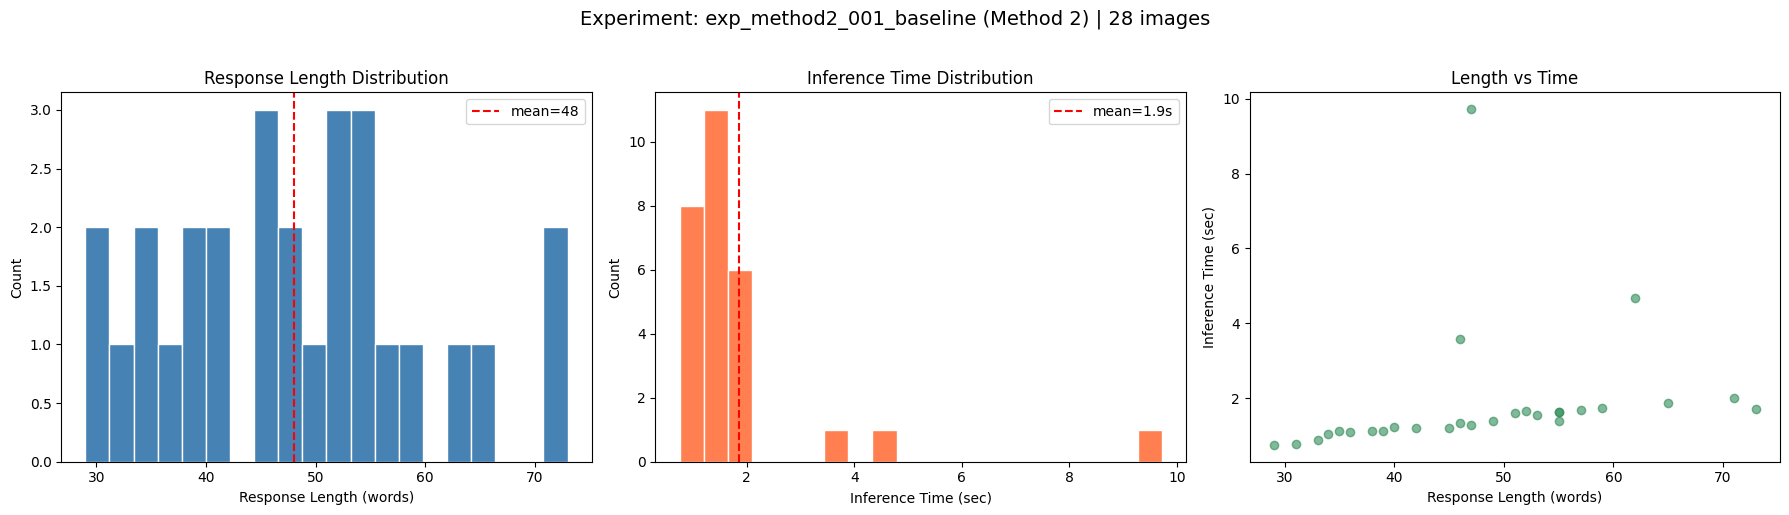

Plot saved to outputs/exp_method2_001_baseline/stats_20260310_131936.png


In [8]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# 응답 단어 수 분포
axes[0].hist(df_results["n_words"], bins=20, color="steelblue", edgecolor="white")
axes[0].set_xlabel("Response Length (words)")
axes[0].set_ylabel("Count")
axes[0].set_title("Response Length Distribution")
axes[0].axvline(df_results["n_words"].mean(), color="red", linestyle="--",
                label=f'mean={df_results["n_words"].mean():.0f}')
axes[0].legend()

# 추론 시간 분포
axes[1].hist(df_results["time_sec"], bins=20, color="coral", edgecolor="white")
axes[1].set_xlabel("Inference Time (sec)")
axes[1].set_ylabel("Count")
axes[1].set_title("Inference Time Distribution")
axes[1].axvline(df_results["time_sec"].mean(), color="red", linestyle="--",
                label=f'mean={df_results["time_sec"].mean():.1f}s')
axes[1].legend()

# 단어 수 vs 추론 시간
axes[2].scatter(df_results["n_words"], df_results["time_sec"], alpha=0.6, color="seagreen")
axes[2].set_xlabel("Response Length (words)")
axes[2].set_ylabel("Inference Time (sec)")
axes[2].set_title("Length vs Time")

plt.suptitle(f"Experiment: {EXPERIMENT_NAME} (Method 2) | {len(df_results)} images",
             fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, f"stats_{timestamp}.png"), dpi=150, bbox_inches="tight")
plt.show()
print(f"Plot saved to {OUTPUT_DIR}/stats_{timestamp}.png")

## 9. Biomarker 키워드 매칭 분석

모델 응답에서 주요 OCT biomarker 키워드가 얼마나 감지되었는지 분석합니다.

In [9]:
import re

# 주요 OCT biomarker 키워드
BIOMARKERS = [
    "drusen", "fluid", "subretinal fluid", "intraretinal fluid",
    "PED", "pigment epithelial detachment",
    "atrophy", "geographic atrophy", "RPE atrophy",
    "SHRM", "subretinal hyperreflective material",
    "ERM", "epiretinal membrane",
    "edema", "macular edema", "cystoid",
    "CNV", "choroidal neovascularization",
    "hypertransmission",
    "AMD", "age-related macular degeneration",
    "DME", "diabetic macular edema",
]

# 진단 키워드
DIAGNOSES = [
    "wet AMD", "dry AMD", "nAMD", "neovascular AMD",
    "diabetic retinopathy", "DME",
    "macular hole", "vitreomacular traction",
    "central serous", "CSC",
    "retinal vein occlusion", "RVO",
    "normal", "healthy",
]

def extract_keywords(text, keyword_list):
    found = []
    text_lower = text.lower()
    for kw in keyword_list:
        if kw.lower() in text_lower:
            found.append(kw)
    return found

# 각 응답에서 키워드 추출
biomarker_counts = Counter()
diagnosis_counts = Counter()

for r in results:
    resp = r["response"]
    bm = extract_keywords(resp, BIOMARKERS)
    dx = extract_keywords(resp, DIAGNOSES)
    r["biomarkers_found"] = bm
    r["diagnoses_found"] = dx
    for b in bm:
        biomarker_counts[b] += 1
    for d in dx:
        diagnosis_counts[d] += 1

# 요약
print("=" * 50)
print("Biomarker Detection Summary")
print("=" * 50)
for kw, cnt in biomarker_counts.most_common():
    pct = cnt / len(results) * 100
    print(f"  {kw:<40s} {cnt:>3d}/{len(results)} ({pct:.0f}%)")

print(f"\n{'=' * 50}")
print("Diagnosis Summary")
print("=" * 50)
for kw, cnt in diagnosis_counts.most_common():
    pct = cnt / len(results) * 100
    print(f"  {kw:<40s} {cnt:>3d}/{len(results)} ({pct:.0f}%)")

avg_bm = np.mean([len(r["biomarkers_found"]) for r in results])
print(f"\nAvg biomarkers per image: {avg_bm:.1f}")

Biomarker Detection Summary
  fluid                                     28/28 (100%)
  atrophy                                   24/28 (86%)
  AMD                                       21/28 (75%)
  drusen                                    20/28 (71%)
  subretinal fluid                          17/28 (61%)
  intraretinal fluid                        15/28 (54%)
  hypertransmission                         12/28 (43%)
  RPE atrophy                               11/28 (39%)
  subretinal hyperreflective material        7/28 (25%)
  PED                                        5/28 (18%)
  SHRM                                       5/28 (18%)
  ERM                                        2/28 (7%)
  age-related macular degeneration           1/28 (4%)

Diagnosis Summary
  wet AMD                                   13/28 (46%)
  healthy                                    4/28 (14%)
  normal                                     3/28 (11%)
  dry AMD                                    2/28 (7%)

Av

## 10. Biomarker Heatmap 시각화

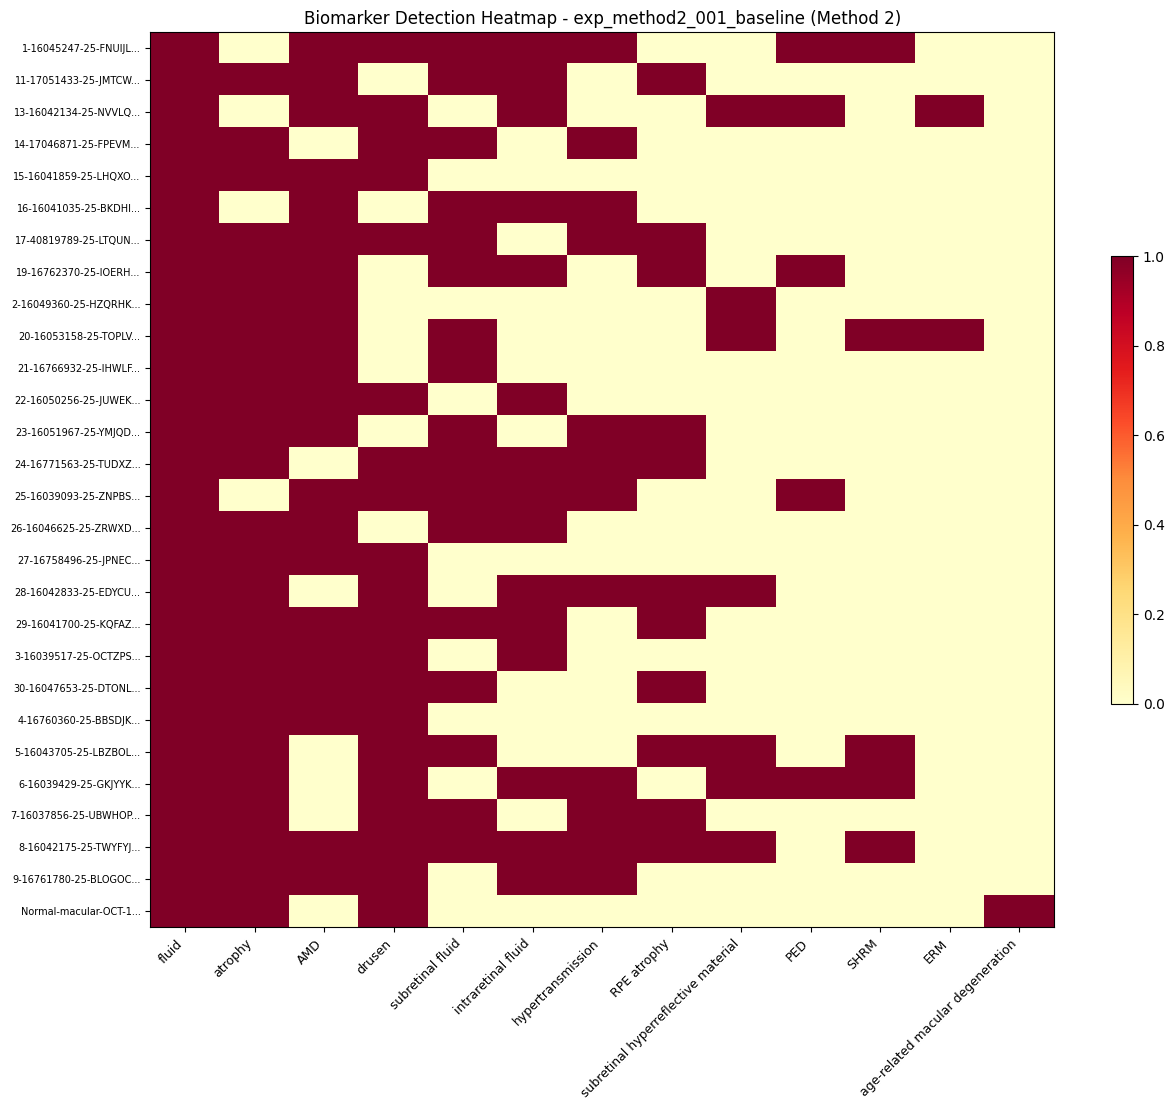

In [10]:
detected_bm = [kw for kw, _ in biomarker_counts.most_common() if biomarker_counts[kw] > 0]

if detected_bm:
    heatmap_data = []
    img_labels = []
    for r in results:
        row = [1 if kw in r["biomarkers_found"] else 0 for kw in detected_bm]
        heatmap_data.append(row)
        img_labels.append(r["image"][:20] + "...")

    heatmap_arr = np.array(heatmap_data)

    fig, ax = plt.subplots(figsize=(max(10, len(detected_bm)), max(6, len(results) * 0.4)))
    im = ax.imshow(heatmap_arr, cmap="YlOrRd", aspect="auto")
    ax.set_xticks(range(len(detected_bm)))
    ax.set_xticklabels(detected_bm, rotation=45, ha="right", fontsize=9)
    ax.set_yticks(range(len(img_labels)))
    ax.set_yticklabels(img_labels, fontsize=7)
    ax.set_title(f"Biomarker Detection Heatmap - {EXPERIMENT_NAME} (Method 2)")
    plt.colorbar(im, ax=ax, shrink=0.5)
    plt.tight_layout()
    plt.savefig(os.path.join(OUTPUT_DIR, f"biomarker_heatmap_{timestamp}.png"), dpi=150, bbox_inches="tight")
    plt.show()
else:
    print("No biomarkers detected in any response.")

## 11. 개별 결과 확인

특정 이미지의 OCT 스캔과 모델 응답을 나란히 확인합니다.

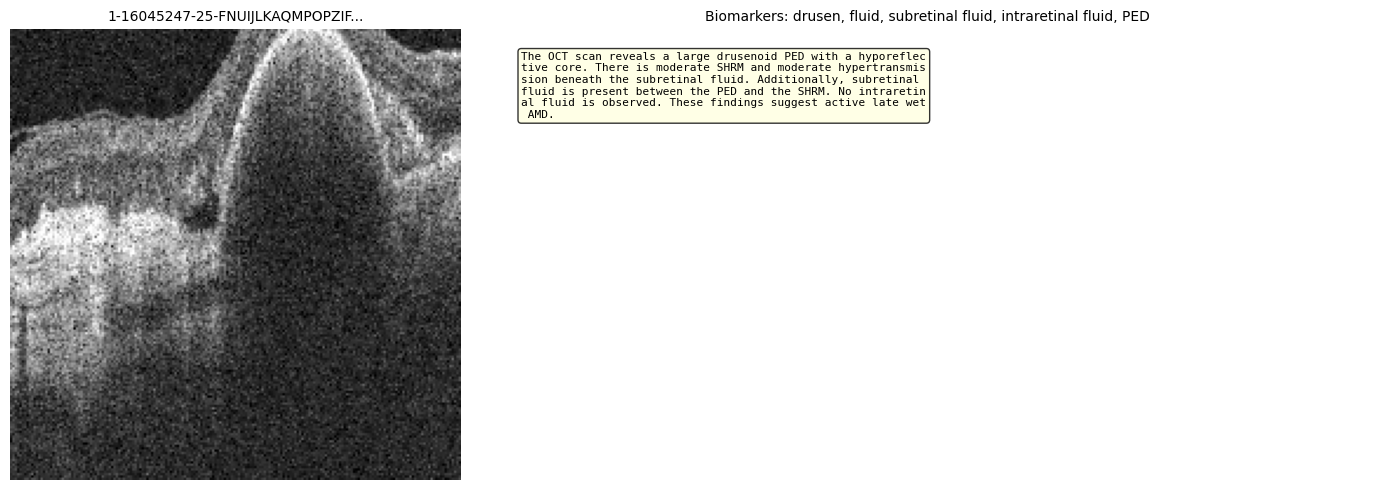

Time: 3.58s | Words: 46 | Diagnoses: ['wet AMD']
----------------------------------------------------------------------


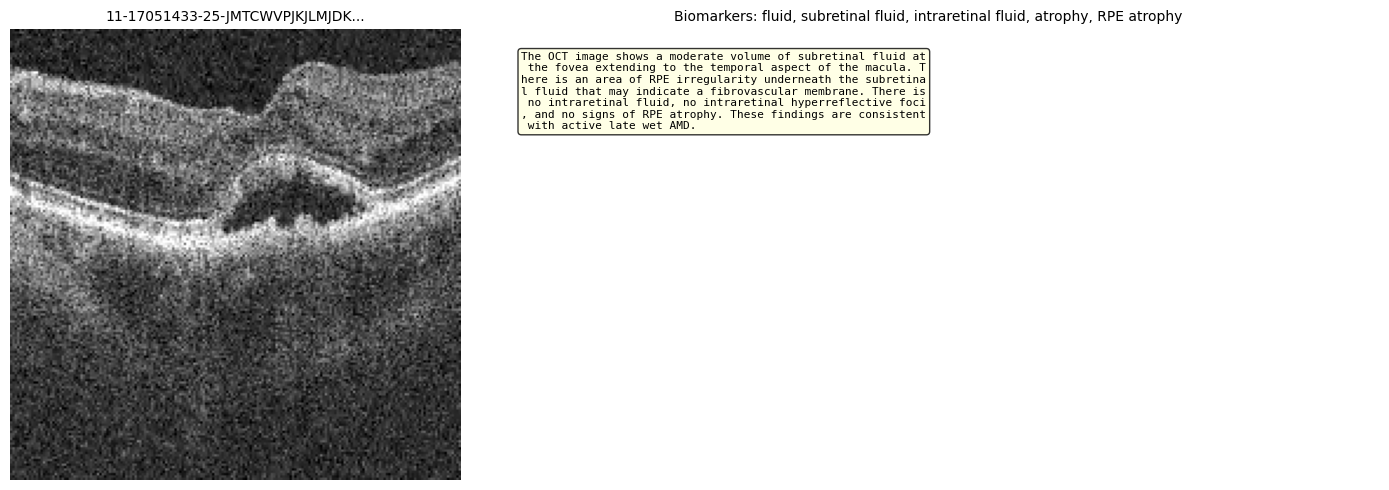

Time: 4.67s | Words: 62 | Diagnoses: ['wet AMD']
----------------------------------------------------------------------


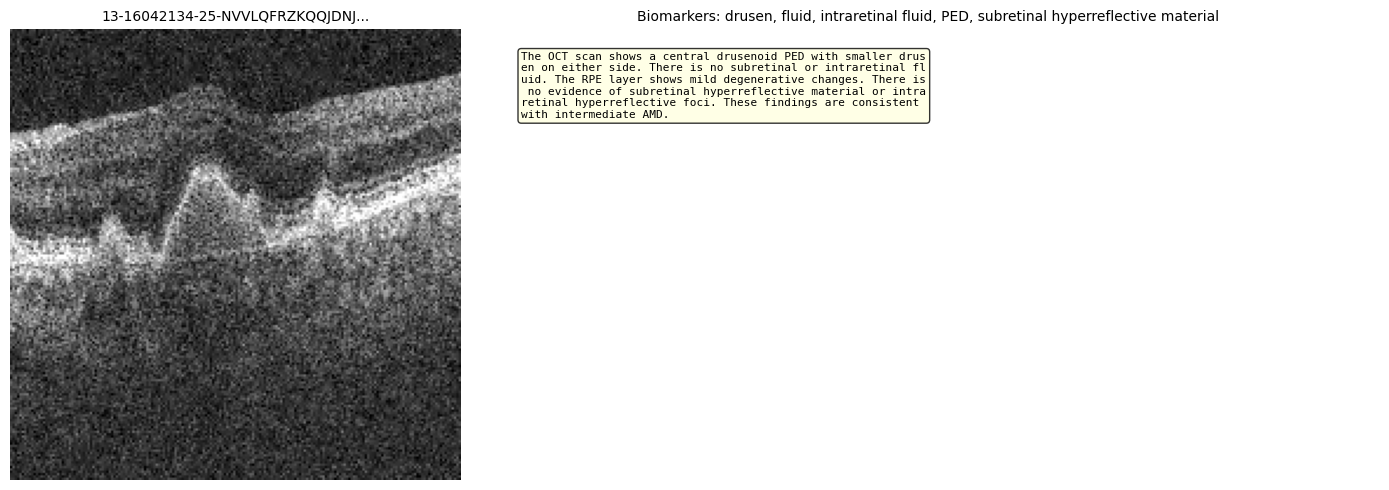

Time: 9.72s | Words: 47 | Diagnoses: []
----------------------------------------------------------------------


In [11]:
def show_result(idx):
    """idx번째 결과를 이미지 + 응답으로 표시"""
    r = results[idx]
    img = Image.open(os.path.join(IMAGE_DIR, r["image"])).convert("L")

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5), gridspec_kw={"width_ratios": [1, 2]})

    ax1.imshow(np.array(img), cmap="gray")
    ax1.set_title(r["image"][:30] + "...", fontsize=10)
    ax1.axis("off")

    # 텍스트 표시
    response_text = r["response"]
    wrapped = "\n".join([response_text[i:i+60] for i in range(0, len(response_text), 60)])
    ax2.text(0.05, 0.95, wrapped, transform=ax2.transAxes,
             fontsize=8, verticalalignment="top", fontfamily="monospace",
             bbox=dict(boxstyle="round", facecolor="lightyellow", alpha=0.8))
    ax2.set_title(f"Biomarkers: {', '.join(r.get('biomarkers_found', [])[:5])}", fontsize=10)
    ax2.axis("off")

    plt.tight_layout()
    plt.show()
    print(f"Time: {r['time_sec']}s | Words: {r['n_words']} | Diagnoses: {r.get('diagnoses_found', [])}")

# 첫 3개 결과 확인
for i in range(min(3, len(results))):
    show_result(i)
    print("-" * 70)

## 12. 쿼리 비교 실험

여러 쿼리 타입으로 동일 이미지에 대해 응답을 비교합니다.

In [12]:
# 첫 번째 이미지로 모든 쿼리 비교
test_image_path = image_files[0]
test_tensor = preprocess_image(test_image_path)

print(f"Image: {os.path.basename(test_image_path)}")
print("=" * 70)

comparison_results = {}
for qname, qtext in QUERIES.items():
    start = time.time()
    with torch.no_grad():
        out = model.query(
            test_tensor,
            [qtext],
            answer_preamble=[''],
            max_new_tokens=MAX_NEW_TOKENS,
            output_only=True,
            return_samples=False,
        )
    elapsed = time.time() - start
    comparison_results[qname] = {"response": out[0], "time": elapsed}

    print(f"\n[{qname}] ({elapsed:.1f}s)")
    print(f"Q: {qtext[:80]}...")
    print(f"A: {out[0]}")
    print("-" * 70)

# 비교 결과 저장
comp_path = os.path.join(OUTPUT_DIR, f"query_comparison_{timestamp}.json")
with open(comp_path, "w", encoding="utf-8") as f:
    json.dump({
        "image": os.path.basename(test_image_path),
        "method": "method2_hf_direct",
        "comparisons": {k: v for k, v in comparison_results.items()}
    }, f, ensure_ascii=False, indent=2)
print(f"\nComparison saved: {comp_path}")

/home/ubuntu/bionexus/jgy/OCT_LLM_XAI/SpecialistVLMs/models/mini_gpt4.py:167: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  return torch.cuda.amp.autocast(dtype=dtype)
Setting `pad_token_id` to `eos_token_id`:128009 for open-end generation.


Image: 1-16045247-25-FNUIJLKAQMPOPZIFPBDWMNIKO+XKIVNLSMJGTAWALNGKBBPCEUAIVZAMYGBVJTB+KVGBEV.png
Inputs torch.Size([1, 112, 4096])


Setting `pad_token_id` to `eos_token_id`:128009 for open-end generation.



[report] (1.4s)
Q: Write a detailed clinical report describing this OCT scan. Identify any visible ...
A: The OCT scan reveals a large drusenoid PED with a hyporeflective core. There is moderate SHRM and moderate hypertransmission beneath the subretinal fluid. Additionally, subretinal fluid is present between the PED and the SHRM. No intraretinal fluid is observed. These findings suggest active late wet AMD.
----------------------------------------------------------------------
Inputs torch.Size([1, 105, 4096])


Setting `pad_token_id` to `eos_token_id`:128009 for open-end generation.



[biomarker] (0.7s)
Q: List all visible biomarkers in this OCT image and their severity (mild, moderate...
A: The image shows a large drusenoid PED, moderate SHRM, moderate hypertransmission beneath the SHRM, subretinal fluid, and intraretinal fluid.
----------------------------------------------------------------------
Inputs torch.Size([1, 101, 4096])

[diagnosis] (1.2s)
Q: Based on this OCT scan, what is the most likely diagnosis? Provide reasoning....
A: The most likely diagnosis is late wet AMD. This is due to the presence of a large drusenoid PED with a hyporeflective core, moderate SHRM, moderate hypertransmission beneath the SHRM, subretinal fluid between the PED and subretinally, and intraretinal fluid.
----------------------------------------------------------------------

Comparison saved: outputs/exp_method2_001_baseline/query_comparison_20260310_131936.json
